# Tier-1 prototype — per-agent forcing efficacy $E_\text{aero}$

Second notebook in the pattern-mediated-feedback series. Notebook 01 showed that CICERO-SCM's diagnosed $\lambda_\text{diff}(t)$ is structurally flat. This notebook implements the simplest possible fix from `../../pattern_mediated_feedback_scm.md` §3: **Tier 1**, a static per-agent forcing efficacy.

> **What Tier 1 does and doesn't change.** Tier 1 is a **forcing rescaling**, not a feedback change. The thermal model's radiative damping coefficient ($1/\lambda_\text{pamset}$) is *untouched* — we simply drive the energy balance with an amplified aerosol forcing. The real climate state changes (temperature, ocean heat uptake, hemispheric contrast all respond to the rescaled input, so it is genuinely prognostic), but no new physical mechanism is introduced inside the model.
>
> The apparent time variation in $\lambda_\text{diff}(t)$ we'll see below is therefore a **diagnostic artefact**: it comes from a mismatch between the forcing that drives the model ($F_\text{eff}$) and the forcing used in the Gregory regression ($F_\text{tot}$). Regressing with $F_\text{eff}$ as reference instead would recover a flat $\lambda_\text{diff}$ for any $E_\text{aero}$. Contrast with Tier 3 (notebook 03), which changes the feedback parameter itself, so $\lambda_\text{diff}$ varies no matter what reference forcing you use.

## Formulation

Replace the forcing that drives the energy balance with an efficacy-weighted sum,

$$F_\text{eff}(t) = \sum_i E_i\,F_i(t)$$

while keeping the *unweighted* total $F_\text{tot} = \sum_i F_i$ as the reference ERF used in the Gregory regression. For a minimal prototype we apply a single efficacy $E_\text{aero}$ to the aerosol tracers and keep $E = 1$ for everything else, so

$$F_\text{eff}(t) = F_\text{tot}(t) + (E_\text{aero} - 1)\,F_\text{aero}(t)$$

## Prototype strategy (no source-code changes)

1. Run CICERO-SCM once in emissions-driven mode (baseline). The model already stores per-agent forcing in `results['forcing']`.
2. Build $F_\text{eff}(t)$ for a target $E_\text{aero}$.
3. Run CICERO-SCM a second time in *forcing-driven* (`rf_run`) mode, feeding $F_\text{eff}$ via `forc_data` as the `total`/`FORC_NH`/`FORC_SH` time series. The model's TOA balance becomes $N = F_\text{eff} - T/\lambda_\text{pamset} - (\varepsilon-1)N_\text{deep}$.
4. Compute $R(t) = N(t) - F_\text{tot}(t)$ using the **unweighted** total from step 1. Regress on $T$ as before.

## Imports, paths, helpers

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))
TEST_DATA = os.path.join(REPO_ROOT, 'tests', 'test-data')

from ciceroscm import CICEROSCM
from ciceroscm.input_handler import read_components, read_inputfile, read_natural_emissions

NYSTART, NYEND = 1750, 2300
LAMBDA_PAMSET = 0.54   # unchanged from notebook 01

# Aerosol tracer set (same as notebook 01)
AEROSOL_TRACERS = ['SO4_DIR', 'SO4_IND', 'BC', 'OC', 'NOx', 'NMVOC', 'NH3', 'BMB_AEROS']

def lambda_diff(T, R, window):
    T = np.asarray(T); R = np.asarray(R)
    out = np.full_like(T, np.nan, dtype=float)
    half = window // 2
    for i in range(half, len(T) - half):
        t_seg = T[i - half: i + half + 1]
        r_seg = R[i - half: i + half + 1]
        v = np.var(t_seg)
        if v <= 0:
            continue
        out[i] = -np.cov(t_seg, r_seg, ddof=0)[0, 1] / v
    return out

## Load SSP2-4.5 inputs

In [2]:
gaspam = read_components(os.path.join(TEST_DATA, 'gases_v1RCMIP.txt'))
df_nat_ch4 = read_natural_emissions(os.path.join(TEST_DATA, 'natemis_ch4.txt'), 'CH4')
df_nat_n2o = read_natural_emissions(os.path.join(TEST_DATA, 'natemis_n2o.txt'), 'N2O')
df_ssp2_conc = read_inputfile(os.path.join(TEST_DATA, 'ssp245_conc_RCMIP.txt'))
emi_input = read_inputfile(os.path.join(TEST_DATA, 'ssp245_em_RCMIP.txt'))
emi_input.rename(columns={'CO2': 'CO2_FF', 'CO2.1': 'CO2_AFOLU'}, inplace=True)

COMMON_UDM = dict(
    threstemp=7.0, rlamdo=16.0, akapa=0.634, cpi=0.4,
    W=4, beto=3.5, mixed=60.0, foan=0.61, foas=0.81,
    ebbeta=0.0, fnso=0.7531, lm=40, ldtime=12,
)
COMMON_UDM['lambda'] = LAMBDA_PAMSET

years = np.arange(NYSTART, NYEND + 1)

## Baseline emissions-driven run

Gives us per-agent forcing time series $F_i(t)$ in `cscm.results['forcing']` and the unweighted total $F_\text{tot}(t) = F$ for the Gregory reference.

In [3]:
cscm_base = CICEROSCM({
    'gaspam_data': gaspam, 'emstart': 1751, 'conc_run': False,
    'nystart': NYSTART, 'nyend': NYEND,
    'concentrations_data': df_ssp2_conc, 'emissions_data': emi_input,
    'nat_ch4_data': df_nat_ch4, 'nat_n2o_data': df_nat_n2o, 'idtm': 24,
})
cscm_base._run(
    {'results_as_dict': True, 'carbon_cycle_outputs': True},
    pamset_udm=dict(COMMON_UDM),
    pamset_emiconc={
        'qbmb': 0.0, 'qo3': 0.5, 'qdirso2': -0.00308,
        'qindso2': -0.97 / 57.052577209999995,
        'qbc': 0.0279, 'qoc': -0.00433, 'qh2o_ch4': 0.091915,
        'ref_yr': 2010,
    },
)

baseline_forc = pd.DataFrame(cscm_base.results['forcing']).set_index('Year')
F_tot = baseline_forc['Total_forcing']                         # unweighted ERF (no solar)
F_aero = baseline_forc[AEROSOL_TRACERS].sum(axis=1)            # aerosol ERF
F_abs_tot = baseline_forc.drop(columns=['Total_forcing']).abs().sum(axis=1)
w_aero = F_aero.abs() / F_abs_tot

print(f'Baseline total forcing in 2014: {F_tot.loc[2014]:.2f} W/m^2')
print(f'Baseline aerosol forcing in 2014: {F_aero.loc[2014]:.2f} W/m^2')
print(f'Aerosol fraction in 2014: {w_aero.loc[2014]:.2%}')

nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


Baseline total forcing in 2014: 1.42 W/m^2
Baseline aerosol forcing in 2014: -2.11 W/m^2
Aerosol fraction in 2014: 32.24%


## Tier-1 run helper

Takes a target $E_\text{aero}$, builds the efficacy-weighted forcing

$$F_\text{eff}(t) = F_\text{tot}(t) + (E_\text{aero}-1)\,F_\text{aero}(t)$$

and runs CICERO-SCM in `rf_run` mode with this forcing. Hemispheric split: we use $F_\text{eff}$ identically for both `FORC_NH` and `FORC_SH`. That's a simplification — aerosols are routed ~90% NH in emissions mode — but for a first prototype the global amplification is what demonstrates the Tier-1 signature. A hemispheric-split version is a follow-up.

`rf_run` adds solar forcing internally inside `forc_set`; we don't prepend it to the input series.

Output: per-year $T$, $N$, plus $R = N - F_\text{tot,baseline}$ using the *unweighted* ERF from the baseline run (so the Gregory regression sees the intended pattern-effect signature).

In [4]:
def build_forcing_df(E_aero):
    F_eff = F_tot + (E_aero - 1.0) * F_aero
    df = pd.DataFrame({'total': F_eff.values,
                       'FORC_NH': F_eff.values,
                       'FORC_SH': F_eff.values},
                      index=F_eff.index.astype(int))
    return df

def tier1_run(E_aero, ocean_efficacy=1.0):
    cscm = CICEROSCM({
        'forc_data': build_forcing_df(E_aero),
        'nystart': NYSTART, 'nyend': NYEND, 'idtm': 24,
    })
    pamset_udm = dict(COMMON_UDM)
    pamset_udm['ocean_efficacy'] = ocean_efficacy
    cscm._run({'results_as_dict': True}, pamset_udm=pamset_udm)
    T = np.asarray(cscm.results['dT_glob']).squeeze()
    N = np.asarray(cscm.results['RIB_glob']).squeeze()
    # R is computed against the UNWEIGHTED baseline ERF, per the brief §3.1
    R = N - F_tot.values
    return pd.DataFrame({'T': T, 'N': N, 'R': R}, index=pd.Index(years, name='year'))

E_values = [1.0, 1.2, 1.5, 1.8]
runs = {E: tier1_run(E) for E in E_values}

# Also record the baseline emissions-mode result as the E=1.0 reference
T_b = np.asarray(cscm_base.results['dT_glob']).squeeze()
N_b = np.asarray(cscm_base.results['RIB_glob']).squeeze()
R_b = N_b - F_tot.values
baseline = pd.DataFrame({'T': T_b, 'N': N_b, 'R': R_b},
                        index=pd.Index(years, name='year'))

# Sanity: E=1.0 (rf_run) should match baseline (emissions-mode) — they'll differ by solar accounting
print('E=1.0 rf_run vs emissions-mode baseline, max |dT|:', np.abs(runs[1.0]['T'].values - T_b).max())

E=1.0 rf_run vs emissions-mode baseline, max |dT|: 0.008508509445811246


## Diagnose $\lambda_\text{diff}(t)$ under each $E_\text{aero}$

In [5]:
WINDOW = 31
ld = {E: lambda_diff(runs[E]['T'].values, runs[E]['R'].values, WINDOW) for E in E_values}

mask_hist = (years >= 1900) & (years <= 2100)
print(f'{WINDOW}-yr window, 1900-2100 stats:')
for E in E_values:
    print(f'  E_aero = {E:.1f}   mean lambda_diff = {np.nanmean(ld[E][mask_hist]):.3f}   '
          f'std = {np.nanstd(ld[E][mask_hist]):.3f}')

31-yr window, 1900-2100 stats:
  E_aero = 1.0   mean lambda_diff = 1.852   std = 0.000
  E_aero = 1.2   mean lambda_diff = 1.408   std = 0.372
  E_aero = 1.5   mean lambda_diff = 0.979   std = 0.618
  E_aero = 1.8   mean lambda_diff = 0.734   std = 0.688


## Key plot — $\lambda_\text{diff}(t)$ under each $E_\text{aero}$

Overlay against the CMIP6 AMIP schematic band (Andrews et al. 2022). We expect the E>1 curves to dip below the $\varepsilon=1$ reference line during the aerosol peak and recover as aerosols decline — the shape follows from the $(E_\text{aero}-1)\,dF_\text{aero}/dT$ term derived above, not from a true pattern effect.

The plot is restricted to 1850–2100 to hide the late-scenario Gregory-regression blow-ups where $F_\text{tot}$ approaches equilibrium and $\mathrm{Var}(T)$ collapses.

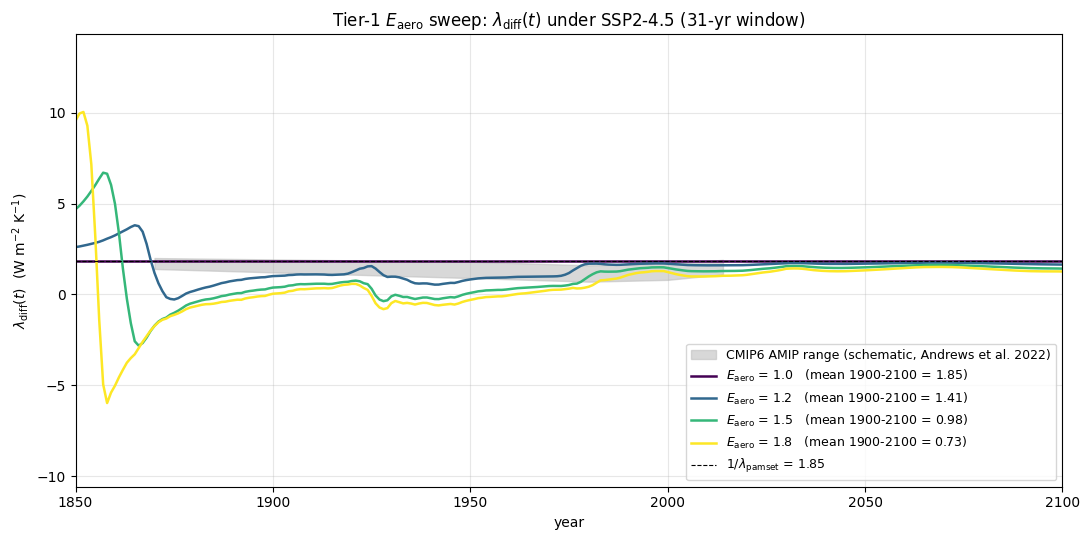

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ref_years = np.array([1870, 1950, 1980, 2000, 2014])
ref_lo    = np.array([1.4,  0.9,  0.7,  0.8,  1.1])
ref_hi    = np.array([2.0,  1.8,  1.6,  1.7,  1.9])
ax.fill_between(ref_years, ref_lo, ref_hi, color='0.75', alpha=0.6,
                label='CMIP6 AMIP range (schematic, Andrews et al. 2022)')

cmap = plt.get_cmap('viridis')
for i, E in enumerate(E_values):
    c = cmap(i / max(1, len(E_values) - 1))
    ax.plot(years, ld[E], color=c, lw=1.8,
            label=rf'$E_\mathrm{{aero}}$ = {E}   (mean 1900-2100 = {np.nanmean(ld[E][mask_hist]):.2f})')

ax.axhline(1.0 / LAMBDA_PAMSET, color='k', ls='--', lw=0.8,
           label=rf'$1/\lambda_\mathrm{{pamset}}$ = {1/LAMBDA_PAMSET:.2f}')
ax.set_xlim(1850, 2100)
ax.set_xlabel('year')
ax.set_ylabel(r'$\lambda_\mathrm{diff}(t)$  (W m$^{-2}$ K$^{-1}$)')
ax.set_title(rf'Tier-1 $E_\mathrm{{aero}}$ sweep: $\lambda_\mathrm{{diff}}(t)$ under SSP2-4.5 ({WINDOW}-yr window)')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()

## Temperature response — the "aerosol unmasking" signature

Larger $E_\text{aero}$ means aerosol cooling is amplified during the industrial peak *and* its subsequent withdrawal unmasks more CO$_2$ warming. Expect: slower historical warming for larger $E_\text{aero}$, followed by stronger 21st-century rebound.

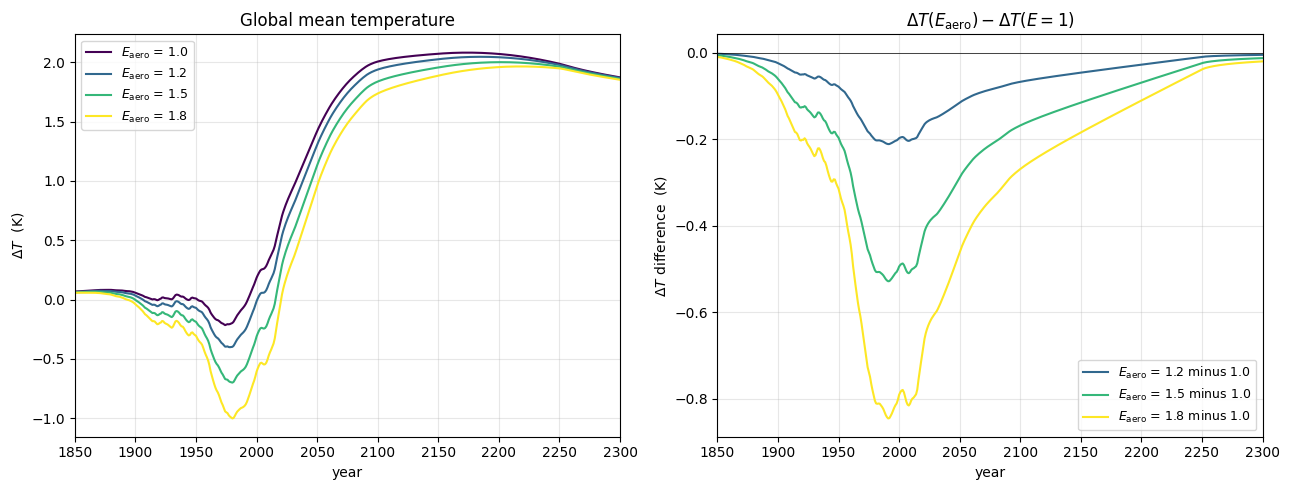

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

cmap = plt.get_cmap('viridis')
for i, E in enumerate(E_values):
    c = cmap(i / max(1, len(E_values) - 1))
    ax[0].plot(years, runs[E]['T'], color=c, lw=1.5, label=rf'$E_\mathrm{{aero}}$ = {E}')

ax[0].set_xlim(1850, 2300); ax[0].set_xlabel('year'); ax[0].set_ylabel(r'$\Delta T$  (K)')
ax[0].set_title('Global mean temperature')
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

# Differences from E=1
for i, E in enumerate(E_values):
    if E == 1.0:
        continue
    c = cmap(i / max(1, len(E_values) - 1))
    ax[1].plot(years, runs[E]['T'] - runs[1.0]['T'], color=c, lw=1.5,
               label=rf'$E_\mathrm{{aero}}$ = {E} minus {1.0}')

ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_xlim(1850, 2300); ax[1].set_xlabel('year'); ax[1].set_ylabel(r'$\Delta T$ difference  (K)')
ax[1].set_title(r'$\Delta T(E_\mathrm{aero}) - \Delta T(E=1)$')
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout()

## Relation to aerosol fraction

For a true pattern effect we'd expect a clean, monotonic scatter of $\lambda_\text{diff}$ against aerosol magnitude fraction. Tier 1's time variation comes from $dF_\text{aero}/dT$, not from $w_\text{aero}$ directly, so the scatter is looser and signed inconsistently across windows — some sections of the curve sit at high $w_\text{aero}$ with low $\lambda_\text{diff}$, others with high $\lambda_\text{diff}$. This is one of the features Tier 3 is designed to fix.

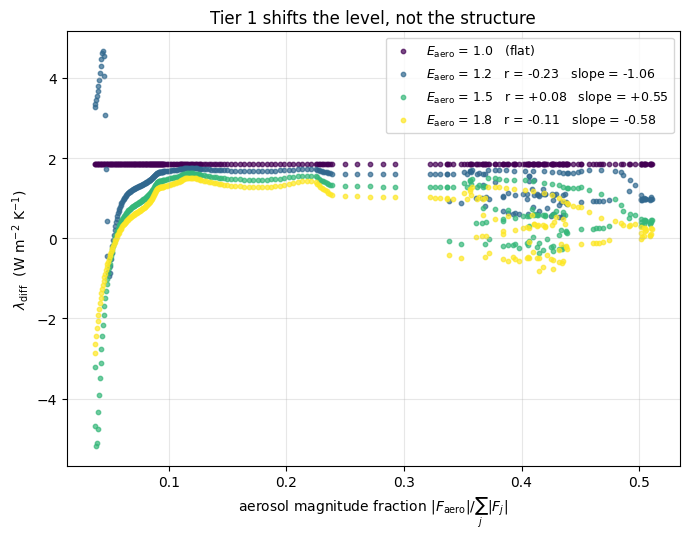

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5))

scatter_mask = ~np.isnan(ld[1.0]) & (years >= 1900) & (years <= 2200)
x = w_aero.loc[years[scatter_mask]].values

cmap = plt.get_cmap('viridis')
for i, E in enumerate(E_values):
    c = cmap(i / max(1, len(E_values) - 1))
    y = ld[E][scatter_mask]
    if np.std(y) > 1e-10:
        r_val = np.corrcoef(x, y)[0, 1]
        slope, intercept = np.polyfit(x, y, 1)
        lbl = rf'$E_\mathrm{{aero}}$ = {E}   r = {r_val:+.2f}   slope = {slope:+.2f}'
    else:
        lbl = rf'$E_\mathrm{{aero}}$ = {E}   (flat)'
    ax.scatter(x, y, s=10, color=c, alpha=0.7, label=lbl)

ax.set_xlabel(r'aerosol magnitude fraction $|F_\mathrm{aero}|/\sum_j|F_j|$')
ax.set_ylabel(r'$\lambda_\mathrm{diff}$  (W m$^{-2}$ K$^{-1}$)')
ax.set_title('Tier 1 shifts the level, not the structure')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()

## Interpretation and next step

**What the run showed (E_aero sweep 1.0 → 1.8 under SSP2-4.5):**
- Mean $\lambda_\text{diff}$(1900–2100) moves from 1.85 → 1.41 → 0.98 → 0.73. Monotonic decrease with $E_\text{aero}$, as predicted — the observer sees a weaker apparent feedback when the thermal model is driven by a stronger net forcing than what the observer attributes.
- Time variation is non-zero: std grows from 0.00 → 0.37 → 0.62 → 0.69 W m$^{-2}$ K$^{-1}$. For $E_\text{aero} \approx 1.5$, the historical-period std is comparable to the CMIP6 AMIP envelope. The qualitative shape — lower $\lambda_\text{diff}$ around the mid-20th-century aerosol peak, recovering into the 21st century — also resembles AMIP diagnostics, purely from the $(E-1)\,dF_\text{aero}/dT$ mechanism.
- The temperature response shows the textbook aerosol-unmasking signature: historical warming suppressed by up to ~0.85 K at $E_\text{aero}$ = 1.8, with stronger 21st-century rebound once aerosol forcing withdraws.

**What Tier 1 is actually doing, vs what a pattern effect does.** Tier 1's time variation is an artefact of the *metric* (Gregory regression confuses the weighted and unweighted forcings), not of the *physics* (the feedback itself is still a single constant $1/\lambda_\text{pamset}$). Two tells:
1. The scatter of $\lambda_\text{diff}$ against aerosol magnitude fraction is not clean or monotonic — correlations are weak and signed inconsistently across $E_\text{aero}$ values (r between $-0.23$ and $+0.08$).
2. In a period where $F_\text{aero}$ happens to be flat (say, a future plateau), Tier 1's time-variation term $(E-1)\,dF_\text{aero}/dT$ vanishes and $\lambda_\text{diff}$ goes back to the $\varepsilon = 1$ line — even though aerosol fraction could still be large. A true pattern effect would keep $\lambda_\text{diff}$ shifted.

**What Tier 1 *is* useful for:** calibration against an observational constraint on historical ECS bias. The mean shift is well-defined and $E_\text{aero}$ can be identified from single-forcing AMIP Gregory slopes. It's the right knob if you want to match the *level* of $\lambda_\text{diff}$ during the historical period, and it will recover the aerosol-unmasking warming signature.

**Proposed next notebook:**
- `03_tier3_aerosol_feedback_shift.ipynb`: implement $\lambda_\text{eff}(t) = \lambda_0 + \Delta\lambda_\text{aero} \cdot |F_\text{aero}| / \sum_j |F_j|$ using the magnitude-weighted fraction (brief §5.5), and show that $\lambda_\text{diff}(t)$ tracks $w_\text{aero}(t)$ cleanly rather than $dF_\text{aero}/dT$.

**Caveats for this prototype:**
- The hemispheric split for $F_\text{eff}$ uses the global value for both `FORC_NH` and `FORC_SH`. The emissions-mode baseline routes aerosols ~90% NH, so a hemispherically-split Tier-1 prototype would show a slightly different NH/SH temperature contrast. Not a barrier to the conceptual demonstration, but worth fixing before any calibration.
- E=1.0 rf_run vs emissions-mode baseline agree on $\Delta T$ to within ~0.009 K — the residual is the solar-forcing accounting difference between the two code paths. Negligible for this diagnostic.
- `ocean_efficacy` is held at 1.0 throughout so that any non-flat $\lambda_\text{diff}(t)$ traces cleanly to Tier-1 behaviour. Notebook 01 already showed that $\varepsilon \ne 1$ introduces scenario-confounded drift that would muddle this diagnosis.